1 - LOADING FILE

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('ai_job_dataset1.csv')


2 - Data Cleaning

In [52]:
df.head()


,job_id,job_title,salary_usd,salary_currency,salary_local,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,Data Scientist,219728,USD,219728,EX,PT,Sweden,M,Sweden,0,"Python, Computer Vision, R, Docker",Associate,13,Transportation,2024-09-23,2024-10-31,1132,6.6,TechCorp Inc
1,AI00002,Head of AI,230237,JPY,25326070,EX,PT,Japan,L,Japan,50,"Kubernetes, MLOps, Tableau, Python",Bachelor,10,Transportation,2024-07-26,2024-09-12,2299,8.5,Cloud AI Solutions
2,AI00003,Data Engineer,128890,EUR,109557,EX,CT,Germany,S,Germany,100,"Spark, Scala, Hadoop, PyTorch, GCP",Bachelor,12,Automotive,2025-01-19,2025-03-28,1329,5.5,Quantum Computing Inc
3,AI00004,Computer Vision Engineer,96349,USD,96349,MI,FL,Finland,L,Finland,50,"MLOps, Linux, Tableau, Python",PhD,2,Automotive,2024-07-20,2024-09-06,1132,6.8,Cognitive Computing
4,AI00005,Robotics Engineer,63065,EUR,53605,EN,FT,France,S,France,100,"R, Scala, SQL, GCP, Python",Associate,0,Finance,2025-03-16,2025-05-09,2011,9.3,Advanced Robotics


3 - Check for missing data

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   salary_local            15000 non-null  int64  
 5   experience_level        15000 non-null  object 
 6   employment_type         15000 non-null  object 
 7   company_location        15000 non-null  object 
 8   company_size            15000 non-null  object 
 9   employee_residence      15000 non-null  object 
 10  remote_ratio            15000 non-null  int64  
 11  required_skills         15000 non-null  object 
 12  education_required      15000 non-null  object 
 13  years_experience        15000 non-null  int64  
 14  industry                15000 non-null

In [54]:
df.shape

(15000, 20)

4 - Check if the columns have the right type

In [55]:
df.dtypes

job_id                     object
job_title                  object
salary_usd                  int64
salary_currency            object
salary_local                int64
experience_level           object
employment_type            object
company_location           object
company_size               object
employee_residence         object
remote_ratio                int64
required_skills            object
education_required         object
years_experience            int64
industry                   object
posting_date               object
application_deadline       object
job_description_length      int64
benefits_score            float64
company_name               object
dtype: object

In [56]:
df.nunique()

job_id                    15000
job_title                    20
salary_usd                14359
salary_currency               8
salary_local              14458
experience_level              4
employment_type               4
company_location             20
company_size                  3
employee_residence           50
remote_ratio                  3
required_skills           13651
education_required            4
years_experience             20
industry                     15
posting_date                486
application_deadline        543
job_description_length     2000
benefits_score               51
company_name                 16
dtype: int64

In [57]:
df.describe(include="all")

,job_id,job_title,salary_usd,salary_currency,salary_local,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
count,15000,15000,15000.000000,15000,1.500000e+04,15000,15000,15000,15000,15000,15000.000000,15000,15000,15000.000000,15000,15000,15000,15000.000000,15000.000000,15000
unique,15000,20,NaN,8,NaN,4,4,20,3,50,NaN,13651,4,NaN,15,486,543,NaN,NaN,16
top,AI15000,Machine Learning Engineer,NaN,USD,NaN,EX,CT,Switzerland,L,Switzerland,NaN,"Python, TensorFlow, Tableau",Bachelor,NaN,Government,2025-04-16,2024-10-07,NaN,NaN,Machine Intelligence Group
freq,1,824,NaN,7453,NaN,3843,3841,819,5087,669,NaN,9,3863,NaN,1035,49,49,NaN,NaN,986
mean,NaN,NaN,121991.938267,NaN,8.292366e+05,NaN,NaN,NaN,NaN,NaN,50.196667,NaN,NaN,6.365667,NaN,NaN,NaN,1500.852600,7.499540,NaN
std,NaN,NaN,63968.361846,NaN,3.425325e+06,NaN,NaN,NaN,NaN,NaN,40.844084,NaN,NaN,5.598551,NaN,NaN,NaN,574.724647,1.444202,NaN
min,NaN,NaN,16621.000000,NaN,1.662100e+04,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,500.000000,5.000000,NaN
25%,NaN,NaN,74978.500000,NaN,7.383075e+04,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,2.000000,NaN,NaN,NaN,998.750000,6.300000,NaN
50%,NaN,NaN,107261.500000,NaN,1.090355e+05,NaN,NaN,NaN,NaN,NaN,50.000000,NaN,NaN,5.000000,NaN,NaN,NaN,1512.000000,7.500000,NaN
75%,NaN,NaN,155752.250000,NaN,1.673278e+05,NaN,NaN,NaN,NaN,NaN,100.000000,NaN,NaN,10.000000,NaN,NaN,NaN,1994.000000,8.800000,NaN


5 - We convert the date columns to datetime64[ns] 

In [58]:
df['posting_date'] = pd.to_datetime(df['posting_date'])
df['application_deadline'] = pd.to_datetime(df['application_deadline'])

In [59]:
df.dtypes

job_id                            object
job_title                         object
salary_usd                         int64
salary_currency                   object
salary_local                       int64
experience_level                  object
employment_type                   object
company_location                  object
company_size                      object
employee_residence                object
remote_ratio                       int64
required_skills                   object
education_required                object
years_experience                   int64
industry                          object
posting_date              datetime64[ns]
application_deadline      datetime64[ns]
job_description_length             int64
benefits_score                   float64
company_name                      object
dtype: object

6 - Droping the columns we do not need

In [60]:
df = df.drop(columns=['salary_currency', 'salary_local', 'posting_date', 'application_deadline', 'job_description_length'])

In [61]:
df.head()

,job_id,job_title,salary_usd,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,benefits_score,company_name
0,AI00001,Data Scientist,219728,EX,PT,Sweden,M,Sweden,0,"Python, Computer Vision, R, Docker",Associate,13,Transportation,6.6,TechCorp Inc
1,AI00002,Head of AI,230237,EX,PT,Japan,L,Japan,50,"Kubernetes, MLOps, Tableau, Python",Bachelor,10,Transportation,8.5,Cloud AI Solutions
2,AI00003,Data Engineer,128890,EX,CT,Germany,S,Germany,100,"Spark, Scala, Hadoop, PyTorch, GCP",Bachelor,12,Automotive,5.5,Quantum Computing Inc
3,AI00004,Computer Vision Engineer,96349,MI,FL,Finland,L,Finland,50,"MLOps, Linux, Tableau, Python",PhD,2,Automotive,6.8,Cognitive Computing
4,AI00005,Robotics Engineer,63065,EN,FT,France,S,France,100,"R, Scala, SQL, GCP, Python",Associate,0,Finance,9.3,Advanced Robotics


# Step 1: Identify Variable Types

Classify your columns into:

Numerical variables (e.g., age, income)

Categorical variables (e.g., gender, country)

This classification determines what types of plots and summary statistics you’ll use.

In [62]:
numerical_cols = df.select_dtypes("int64","float64").columns
print(numerical_cols)

Index(['salary_usd', 'remote_ratio', 'years_experience'], dtype='object')


In [63]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns
print(categorical_cols)

Index(['job_id', 'job_title', 'experience_level', 'employment_type',
       'company_location', 'company_size', 'employee_residence',
       'required_skills', 'education_required', 'industry', 'company_name'],
      dtype='object')


# Step 2: Univariate EDA (One Variable at a Time)

Now, explore each variable individually - but only the ones relevant to your goal.
- For numerical variables:

Use .describe() for summary stats.

Visualize distributions with histograms or boxplots.

- For categorical variables:

Use .value_counts() to see frequency counts.

Visualize with bar plots (or pie charts, if you must).

This step helps you understand the shape, spread, and patterns in your key variables.

Numerical Values:

In [64]:
for col in numerical_cols:
     print(f"\n Summary for {col}:")
     print(df[col].describe())


 Summary for salary_usd:
count     15000.000000
mean     121991.938267
std       63968.361846
min       16621.000000
25%       74978.500000
50%      107261.500000
75%      155752.250000
max      410273.000000
Name: salary_usd, dtype: float64

 Summary for remote_ratio:
count    15000.000000
mean        50.196667
std         40.844084
min          0.000000
25%          0.000000
50%         50.000000
75%        100.000000
max        100.000000
Name: remote_ratio, dtype: float64

 Summary for years_experience:
count    15000.000000
mean         6.365667
std          5.598551
min          0.000000
25%          2.000000
50%          5.000000
75%         10.000000
max         19.000000
Name: years_experience, dtype: float64


<Figure size 1200x800 with 0 Axes>

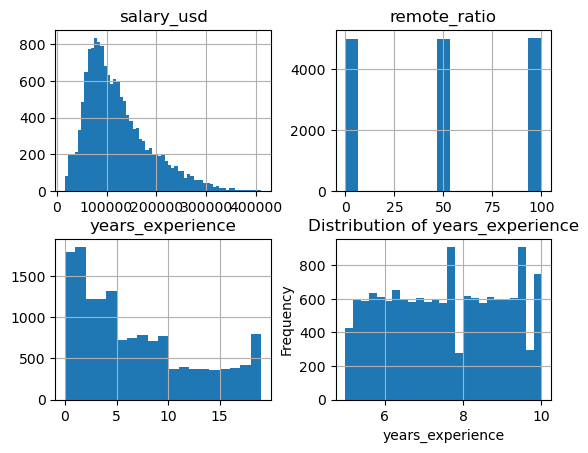

In [65]:
plt.figure(figsize=(12, 8))
df.hist(bins='auto')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

That for interpretation reasons, we store one by one

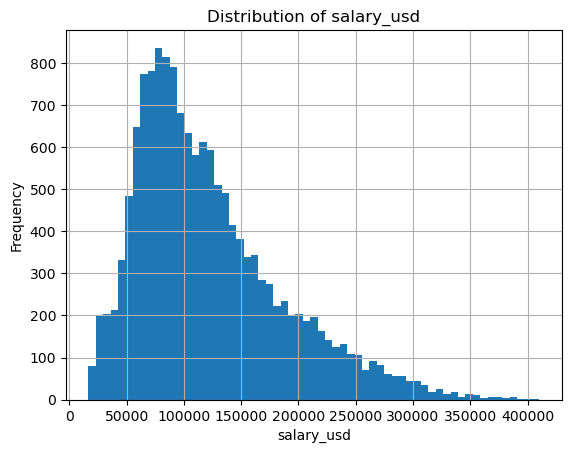

In [66]:
df['salary_usd'].hist(bins='auto')
plt.title(f"Distribution of salary_usd")
plt.xlabel("salary_usd")
plt.ylabel("Frequency")
plt.show()

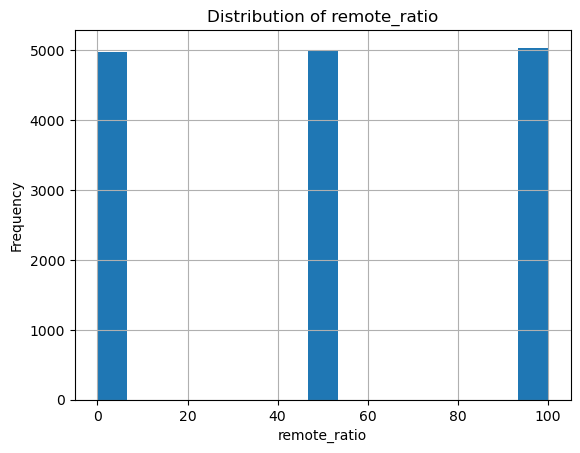

In [67]:
df['remote_ratio'].hist(bins='auto')
plt.title("Distribution of remote_ratio")
plt.xlabel("remote_ratio")
plt.ylabel("Frequency")
plt.show()

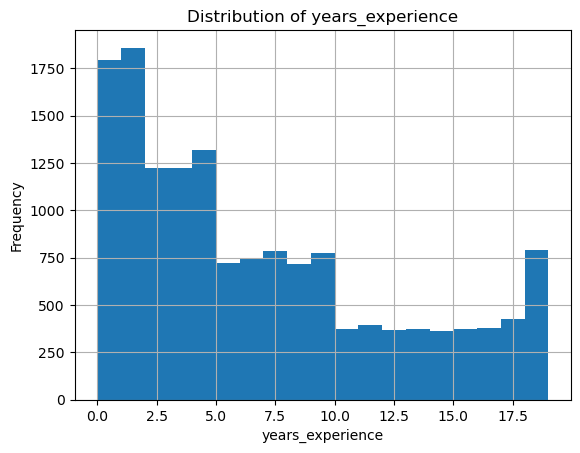

In [68]:
df['years_experience'].hist(bins='auto')
plt.title(f"Distribution of years_experience")
plt.xlabel("years_experience")
plt.ylabel("Frequency")
plt.show()

Categorical Values

In [69]:
for col in categorical_cols:
    print(f'Frequency of the counts for {col}')
    print(df[col].value_counts (dropna=False))

Frequency of the counts for job_id
job_id
AI15000    1
AI00001    1
AI00002    1
AI00003    1
AI00004    1
          ..
AI00013    1
AI00012    1
AI00011    1
AI00010    1
AI00009    1
Name: count, Length: 15000, dtype: int64
Frequency of the counts for job_title
job_title
Machine Learning Engineer      824
Deep Learning Engineer         786
Computer Vision Engineer       780
AI Specialist                  774
Data Engineer                  769
Principal Data Scientist       768
AI Product Manager             764
Data Scientist                 763
Robotics Engineer              762
AI Architect                   758
Autonomous Systems Engineer    755
NLP Engineer                   741
Machine Learning Researcher    734
Data Analyst                   734
Research Scientist             731
AI Software Engineer           730
AI Research Scientist          724
AI Consultant                  713
Head of AI                     701
ML Ops Engineer                689
Name: count, dtype: int64


In [70]:
#Index(['job_id', 'job_title', 'experience_level', 'employment_type',
       #'company_location', 'company_size', 'employee_residence',
       #'required_skills', 'education_required', 'industry', 'company_name'],
      #dtype='object')

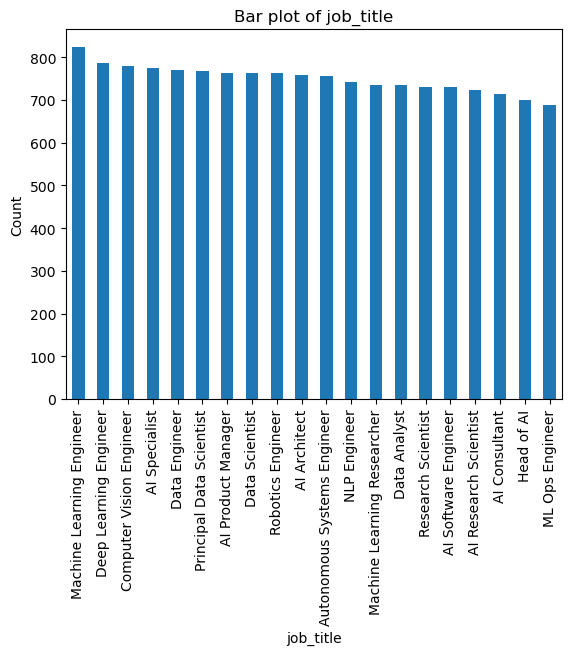

In [71]:
df['job_title'].value_counts().plot(kind='bar')
plt.title(f'Bar plot of job_title')
plt.xlabel('job_title')
plt.ylabel('Count')
plt.show()


In [72]:
df["experience_level"].value_counts(normalize = True)
round(df["experience_level"].value_counts(normalize = True) * 100, 2)

experience_level
EX    25.62
MI    25.09
SE    24.94
EN    24.35
Name: proportion, dtype: float64

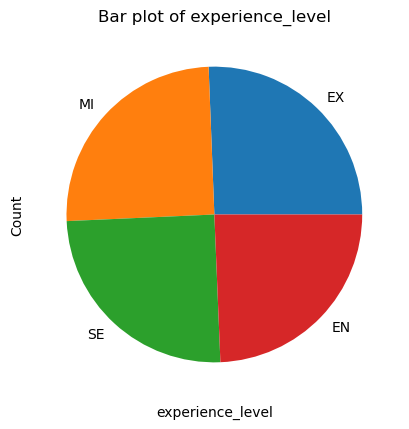

In [73]:
df['experience_level'].value_counts().plot(kind='pie')
plt.title(f'Bar plot of experience_level')
plt.xlabel('experience_level')
plt.ylabel('Count')
plt.show()

# EX - Executive
# MI - Midle management
# SE - Senior level
# EN - Entry level

In [74]:
df["experience_level"].describe()

count     15000
unique        4
top          EX
freq       3843
Name: experience_level, dtype: object

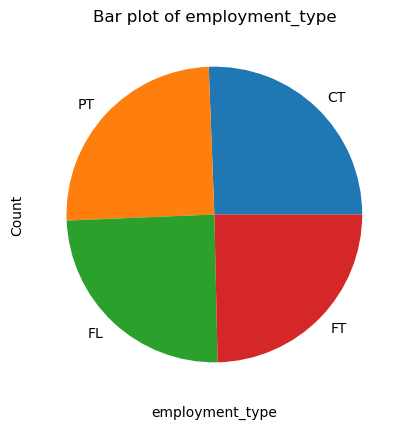

In [75]:
df['employment_type'].value_counts().plot(kind='pie')
plt.title(f'Bar plot of employment_type')
plt.xlabel('employment_type')
plt.ylabel('Count')
plt.show()

In [76]:
df["company_location"].describe()

count           15000
unique             20
top       Switzerland
freq              819
Name: company_location, dtype: object

In [77]:
df["company_location"].value_counts().max

<bound method Series.max of company_location
Switzerland       819
Canada            781
United Kingdom    780
United States     776
Singapore         762
China             760
Denmark           759
Israel            758
Ireland           757
South Korea       755
France            749
Netherlands       748
Germany           746
Japan             742
Norway            739
Sweden            729
Australia         721
Finland           718
India             702
Austria           699
Name: count, dtype: int64>

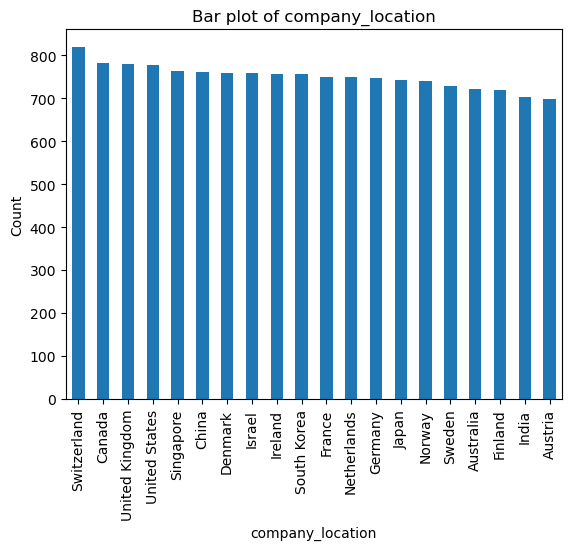

In [78]:
df['company_location'].value_counts().plot(kind='bar')
plt.title(f'Bar plot of company_location')
plt.xlabel('company_location')
plt.ylabel('Count')
plt.show()

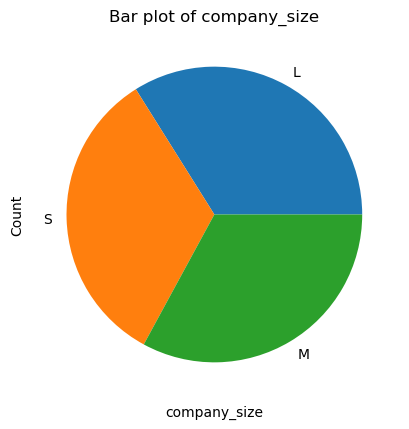

In [79]:
df['company_size'].value_counts().plot(kind='pie')
plt.title(f'Bar plot of company_size')
plt.xlabel('company_size')
plt.ylabel('Count')
plt.show()

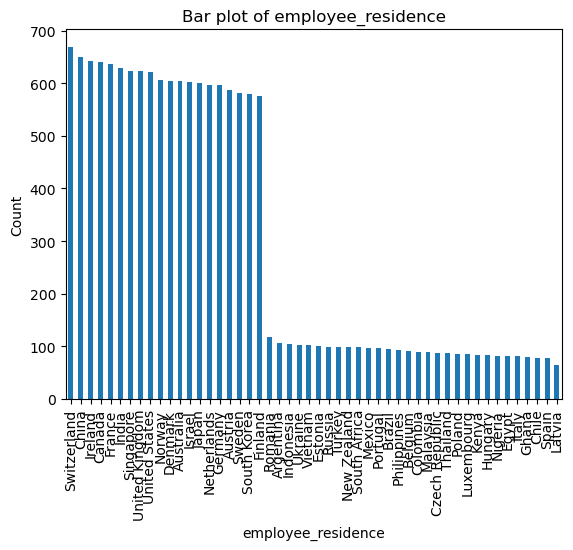

In [80]:
df['employee_residence'].value_counts().plot(kind='bar')
plt.title(f'Bar plot of employee_residence')
plt.xlabel('employee_residence')
plt.ylabel('Count')
plt.show()


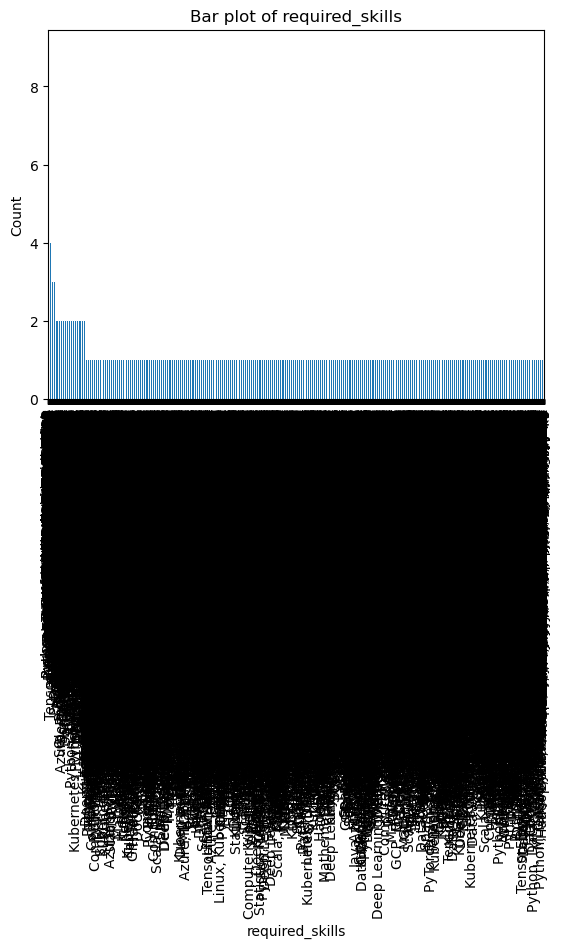

In [81]:
df['required_skills'].value_counts().plot(kind='bar')
plt.title(f'Bar plot of required_skills')
plt.xlabel('required_skills')
plt.ylabel('Count')
plt.show()


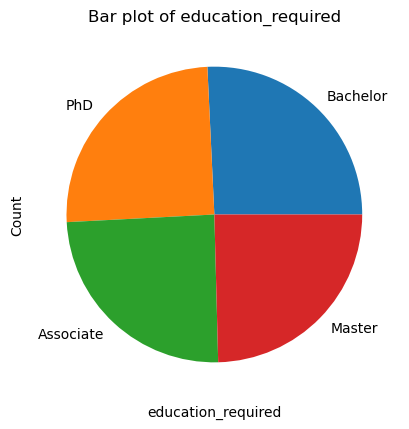

In [82]:
df['education_required'].value_counts().plot(kind='pie')
plt.title(f'Bar plot of education_required')
plt.xlabel('education_required')
plt.ylabel('Count')
plt.show()

In [83]:
df['industry'].describe()

count          15000
unique            15
top       Government
freq            1035
Name: industry, dtype: object

In [84]:
df['industry'].value_counts().max

<bound method Series.max of industry
Government            1035
Manufacturing         1035
Consulting            1021
Finance               1018
Automotive            1015
Technology            1011
Real Estate           1005
Gaming                 999
Telecommunications     995
Education              992
Energy                 989
Healthcare             984
Retail                 978
Media                  972
Transportation         951
Name: count, dtype: int64>

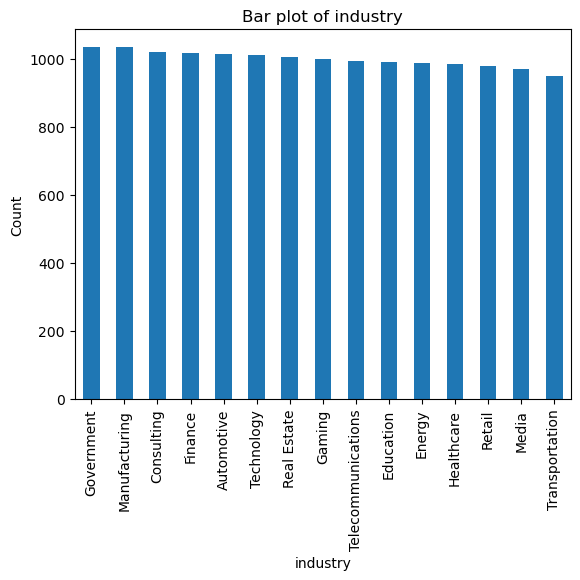

In [85]:
df['industry'].value_counts().plot(kind='bar')
plt.title(f'Bar plot of industry')
plt.xlabel('industry')
plt.ylabel('Count')
plt.show()

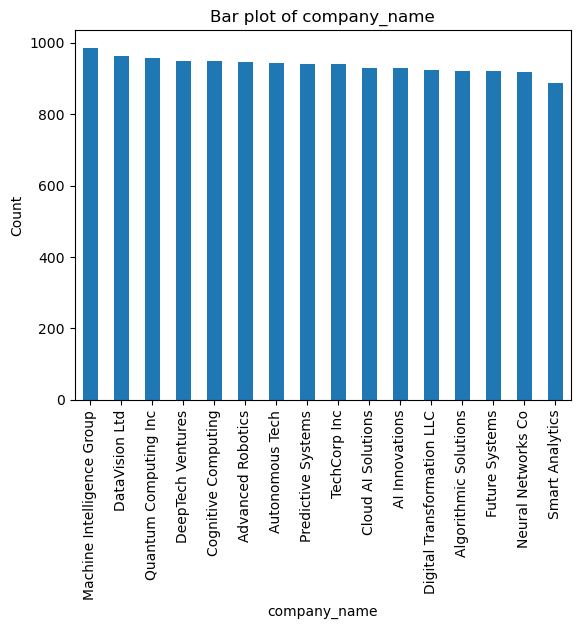

In [86]:
df['company_name'].value_counts().plot(kind='bar')
plt.title(f'Bar plot of company_name')
plt.xlabel('company_name')
plt.ylabel('Count')
plt.show()

## Step 3: Bivariate EDA (Two Variables at a Time)

After univariate EDA, analyze relationships between two or more variables using:

- Grouped summaries (e.g., df.groupby())

- Cross-tabs (e.g., pd.crosstab())

- Scatter plots, bar plots, boxplots, etc.

Again, focus only on the relationships that are relevant to your research question.

In [87]:
df.head()

,job_id,job_title,salary_usd,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,benefits_score,company_name
0,AI00001,Data Scientist,219728,EX,PT,Sweden,M,Sweden,0,"Python, Computer Vision, R, Docker",Associate,13,Transportation,6.6,TechCorp Inc
1,AI00002,Head of AI,230237,EX,PT,Japan,L,Japan,50,"Kubernetes, MLOps, Tableau, Python",Bachelor,10,Transportation,8.5,Cloud AI Solutions
2,AI00003,Data Engineer,128890,EX,CT,Germany,S,Germany,100,"Spark, Scala, Hadoop, PyTorch, GCP",Bachelor,12,Automotive,5.5,Quantum Computing Inc
3,AI00004,Computer Vision Engineer,96349,MI,FL,Finland,L,Finland,50,"MLOps, Linux, Tableau, Python",PhD,2,Automotive,6.8,Cognitive Computing
4,AI00005,Robotics Engineer,63065,EN,FT,France,S,France,100,"R, Scala, SQL, GCP, Python",Associate,0,Finance,9.3,Advanced Robotics


## Question number 1: 
    
    What is the most common education requirement for each type of industry that has A.I employees.

In [88]:
education_industry = df.groupby('education_required')['industry'].value_counts().groupby (level=0).head()

print(education_industry)

education_required  industry          
Associate           Manufacturing         263
                    Retail                263
                    Telecommunications    262
                    Gaming                259
                    Finance               257
Bachelor            Consulting            288
                    Finance               281
                    Government            278
                    Technology            265
                    Automotive            264
Master              Media                 259
                    Healthcare            257
                    Manufacturing         257
                    Real Estate           255
                    Automotive            253
PhD                 Energy                284
                    Manufacturing         270
                    Education             262
                    Government            256
                    Real Estate           255
Name: count, dtype: int64


In [89]:
pd.crosstab(df["education_required"], df["industry"])

industry,Automotive,Consulting,Education,Energy,Finance,Gaming,Government,Healthcare,Manufacturing,Media,Real Estate,Retail,Technology,Telecommunications,Transportation
education_required,,,,,,,,,,,,,,,
Associate,245,247,247,213,257,259,249,222,263,227,237,263,245,262,252
Bachelor,264,288,253,253,281,264,278,258,245,243,258,255,265,243,215
Master,253,244,230,239,249,241,252,257,257,259,255,217,253,242,240
PhD,253,242,262,284,231,235,256,247,270,243,255,243,248,248,244


In [90]:
Edu_industry_precentile = pd.crosstab(df['industry'], df['education_required'], normalize='index')*100
print(Edu_industry_precentile)

education_required  Associate   Bachelor     Master        PhD
industry                                                      
Automotive          24.137931  26.009852  24.926108  24.926108
Consulting          24.191969  28.207640  23.898139  23.702253
Education           24.899194  25.504032  23.185484  26.411290
Energy              21.536906  25.581395  24.165824  28.715875
Finance             25.245580  27.603143  24.459725  22.691552
Gaming              25.925926  26.426426  24.124124  23.523524
Government          24.057971  26.859903  24.347826  24.734300
Healthcare          22.560976  26.219512  26.117886  25.101626
Manufacturing       25.410628  23.671498  24.830918  26.086957
Media               23.353909  25.000000  26.646091  25.000000
Real Estate         23.582090  25.671642  25.373134  25.373134
Retail              26.891616  26.073620  22.188139  24.846626
Technology          24.233432  26.211672  25.024728  24.530168
Telecommunications  26.331658  24.422111  24.321608  24

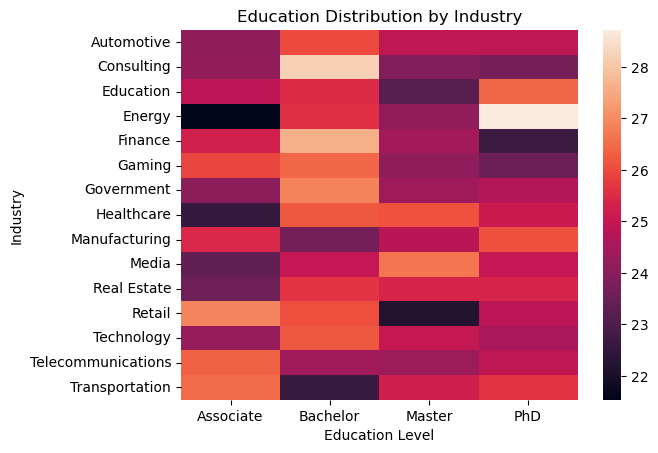

In [91]:
sns.heatmap(data=Edu_industry_precentile)
plt.title ("Education Distribution by Industry")
plt.xlabel('Education Level')
plt.ylabel('Industry')
plt.show()

# Conclusion
No single education level dominates the AI field, it’s balanced, showing that AI welcomes multiple entry paths

Bachelor’s degrees are most common across nearly all industries

PhDs domains in industries like Energy, Manufacturing, and Education.

Associate degrees are more hired industries like finance, retail and telecomunications.

Master’s degrees hold strong presence in Healthcare and Media

## Question number 2
    What is the impact of industry, country and experience level on salary?

In [92]:
#'job_id', 'job_title', 'experience_level', 'employment_type',
       #'company_location', 'company_size', 'employee_residence',
       #'required_skills', 'education_required', 'industry', 'company_name'],


In [93]:
df["salary_usd"].describe()

count     15000.000000
mean     121991.938267
std       63968.361846
min       16621.000000
25%       74978.500000
50%      107261.500000
75%      155752.250000
max      410273.000000
Name: salary_usd, dtype: float64

In [94]:
df.groupby(["industry", "company_location", "experience_level"])["salary_usd"].mean().sort_values(ascending=False).head(15)

industry            company_location  experience_level
Finance             Switzerland       EX                  326320.222222
Gaming              Switzerland       EX                  302313.384615
Retail              Switzerland       EX                  288326.157895
Transportation      Denmark           EX                  288077.333333
Automotive          Switzerland       EX                  288010.923077
Consulting          Switzerland       EX                  284407.058824
Media               Switzerland       EX                  284226.000000
                    Denmark           EX                  283627.312500
Education           Switzerland       EX                  278926.833333
Technology          Switzerland       EX                  277328.363636
Telecommunications  Norway            EX                  275888.700000
Manufacturing       Switzerland       EX                  275858.750000
Transportation      Switzerland       EX                  272755.500000
Technolog

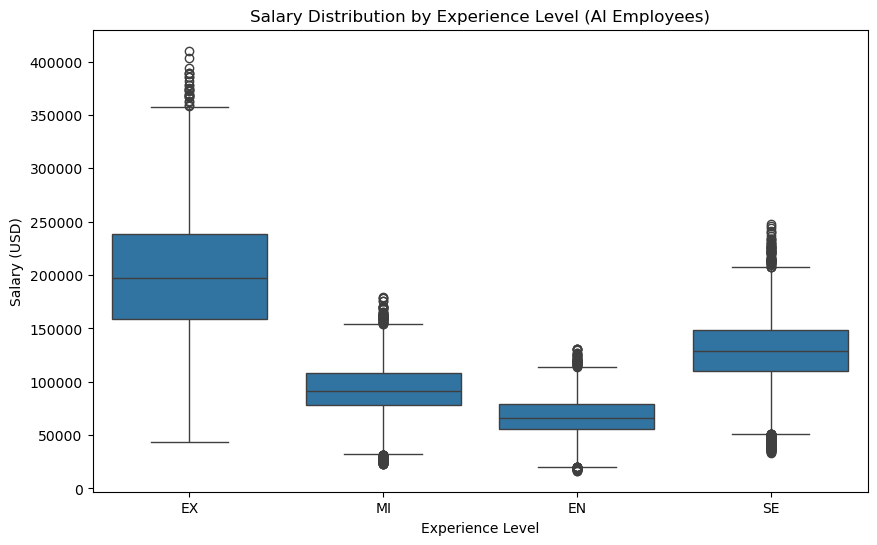

In [95]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="experience_level", y="salary_usd")
plt.title("Salary Distribution by Experience Level (AI Employees)")
plt.xlabel("Experience Level")
plt.ylabel("Salary (USD)")
plt.show()

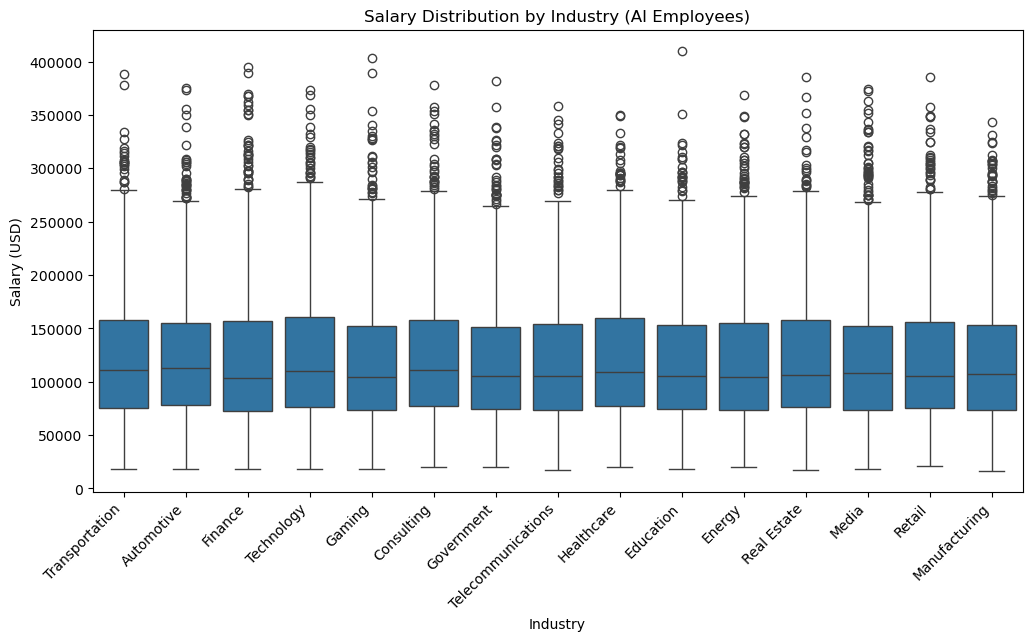

In [96]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="industry", y="salary_usd")
plt.title("Salary Distribution by Industry (AI Employees)")
plt.xlabel("Industry")
plt.ylabel("Salary (USD)")
plt.xticks(rotation=45, ha='right')
plt.show()

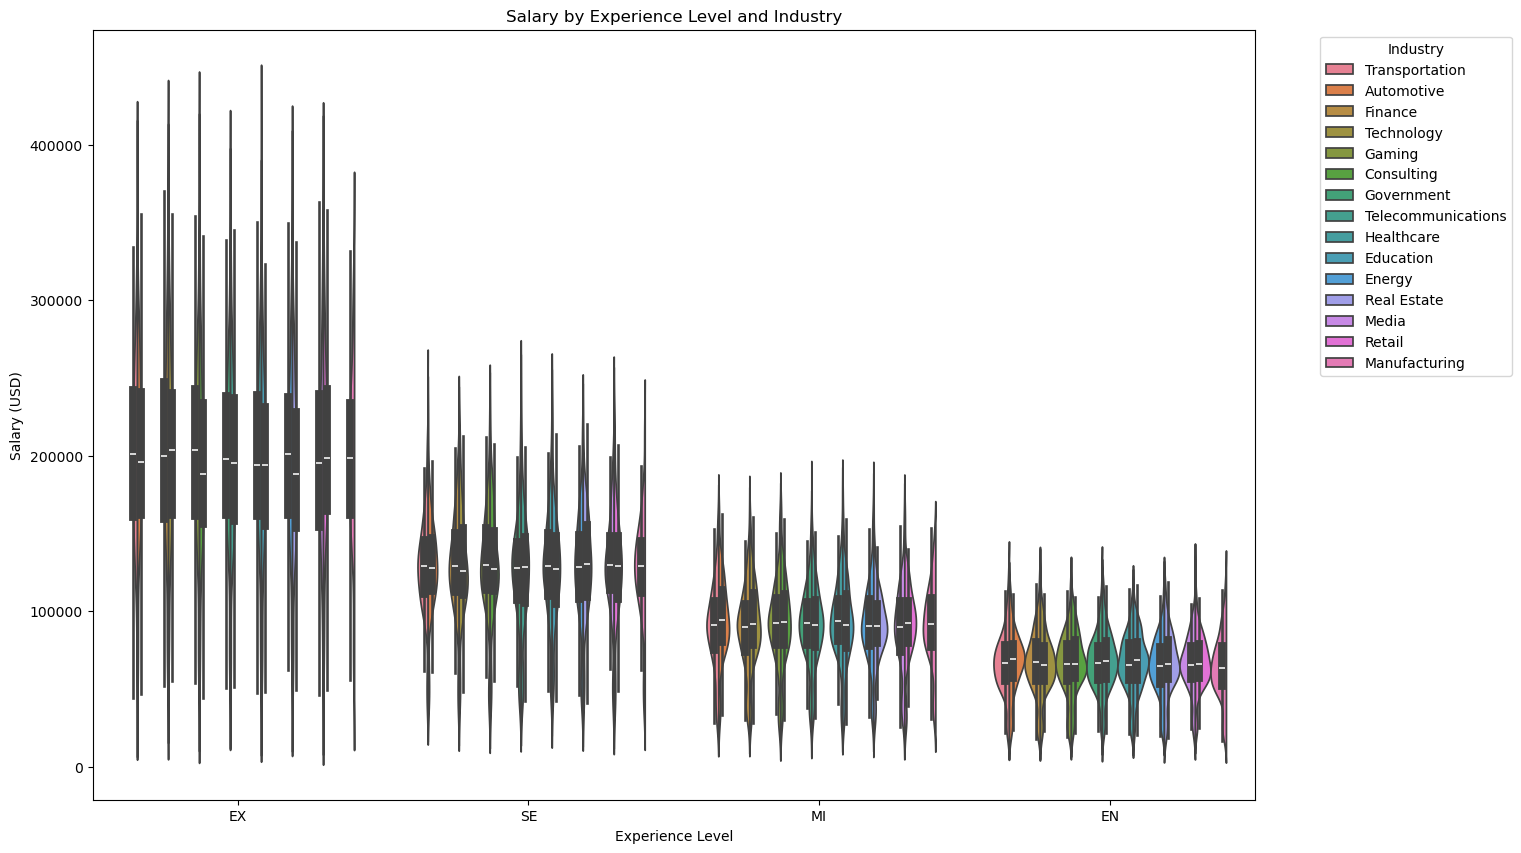

In [107]:
plt.figure(figsize=(15, 10))
sns.violinplot(data=df, x="experience_level", y="salary_usd", hue="industry", split=True, order=["EX", "SE", "MI", "EN"])
plt.title("Salary by Experience Level and Industry")
plt.xlabel("Experience Level")
plt.ylabel("Salary (USD)")
plt.legend(frameon=False, loc='lower center', ncol=2)
plt.legend(title="Industry", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

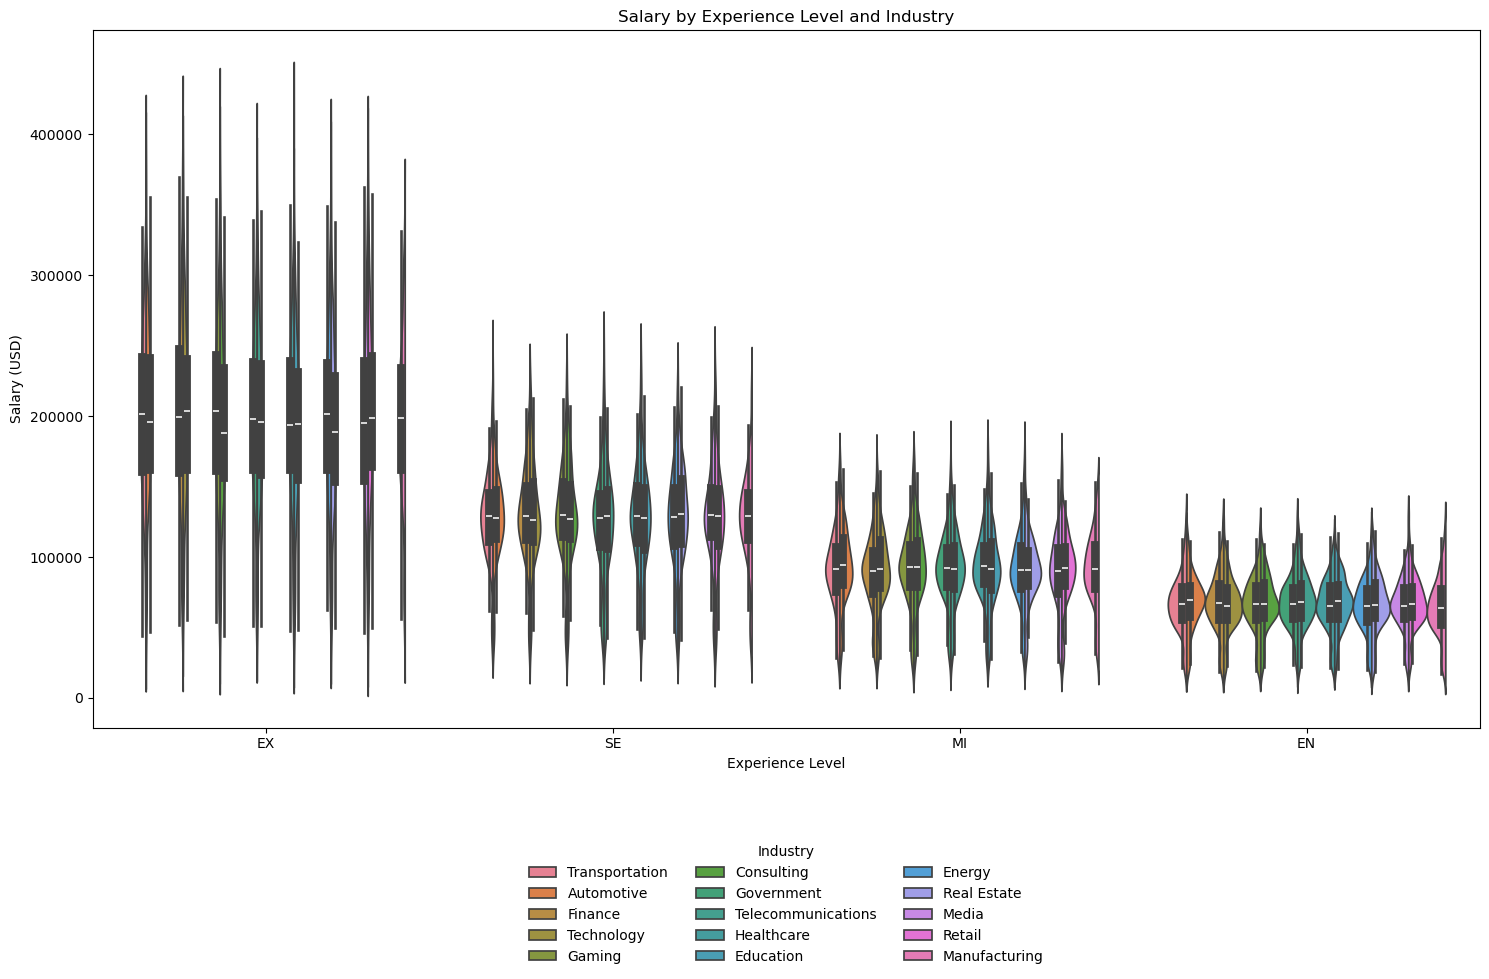

In [109]:
plt.figure(figsize=(15, 10))
sns.violinplot(
    data=df,
    x="experience_level",
    y="salary_usd",
    hue="industry",
    split=True,
    order=["EX", "SE", "MI", "EN"]
)

plt.title("Salary by Experience Level and Industry")
plt.xlabel("Experience Level")
plt.ylabel("Salary (USD)")

# Adjust legend below the plot with multiple rows
plt.legend(
    title="Industry",
    bbox_to_anchor=(0.5, -0.15),  # slightly below the plot
    loc='upper center',
    ncol=3,  # adjust this number to control wrapping (e.g. 2, 3, or 4)
    frameon=False
)

plt.tight_layout()
plt.show()

In [102]:
pivot = pd.pivot_table(df,
                       values="salary_usd",
                       index=["industry"],
                       columns=["experience_level"],
                       aggfunc="mean")
print(pivot.round(0))

experience_level         EN        EX       MI        SE
industry                                                
Automotive          67378.0  199797.0  94807.0  127313.0
Consulting          67359.0  194525.0  93696.0  129118.0
Education           67941.0  192478.0  92511.0  126552.0
Energy              64794.0  201225.0  91489.0  125982.0
Finance             67282.0  203019.0  87885.0  129939.0
Gaming              65808.0  200849.0  91488.0  131108.0
Government          67873.0  197293.0  91077.0  123772.0
Healthcare          66197.0  197044.0  93947.0  128980.0
Manufacturing       64498.0  197315.0  91702.0  126230.0
Media               65979.0  199345.0  88214.0  129013.0
Real Estate         67010.0  189706.0  90166.0  129345.0
Retail              67680.0  202702.0  92255.0  127704.0
Technology          66501.0  204378.0  93359.0  129814.0
Telecommunications  68276.0  197451.0  91123.0  125141.0
Transportation      67190.0  201038.0  90139.0  129199.0


# Salary Distribution

Average salary (USD): ≈ $122K, with a wide spread (std ≈ $64K).

The range is large — from $16K up to $410K, indicating strong inequality in A.I. pay.

Salaries increase sharply with experience level, which we will detail below.

A.I. salaries change significantly, reflecting both experience level and regional economic differences.

# Impact of Experience

Salary growth with experience is very strong — consistent across all industries.
Executives (EX) earn ~3x more than entry-level (EN) employees.

Technology and Finance lead A.I. salaries globally.

# Impact of industry

Education, Consulting, and Real Estate are on the lower end — possibly due to less profit margin or smaller-scale A.I. adoption.

Across all industries, Executive experience consistently yields salaries around $190K–$205K.

# Impact of countries

Western European countries with high cost of living (especially Switzerland) lead in compensation, likely due to both currency strength and advanced AI infrastructure.

# Education and industry

Bachelor’s remains the most common degree overall.

PhDs are concentrated in research-heavy industries (Energy, Manufacturing).

Education level distribution is stable — differences come mainly from experience and geography, not degree type alone.

# Conclusion

Experience and location are the strongest determinants of A.I. salaries.

Industry matters: Tech and Finance consistently lead, while public or creative sectors lag.

Education alone doesn’t drive salary — it supports progression but doesn’t replace experience.

Benefits and salaries rise together, suggesting better employers offer comprehensive compensation packages.

The A.I. job market is globally lucrative, with clear rewards for specialization and seniority.

